# Indoor WiFi Localization using Machine Learning

## Author
**Moaz Abeer**

## Project

This project develops an indoor indoor positioning system using WiFi fingerprinting and machine learning. The dataset is collected using the WiFi Heatmap Analyzer application, transformed into WiFi fingerprints, and used to train multiple machine learning models for predicting indoor locations.

---

## Objectives

- Load WiFi scan data
- Validate and clean the dataset
- Generate WiFi fingerprints
- Perform exploratory data analysis
- Train multiple ML models
- Compare model performance
- Save the best model
- Predict user location from new WiFi scans

---

## Workflow

1. Project Setup
2. Data Loading
3. Data Validation
4. Exploratory Data Analysis
5. Fingerprint Generation
6. Feature Engineering
7. Model Training
8. Model Evaluation
9. Model Comparison
10. Save Best Model
11. Live Prediction

# Section 1 — Project Setup

In [1]:
# ==========================================================
# Section 1 - Import Libraries
# ==========================================================

import os
import glob
import zipfile
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ==========================================================
# Reproducibility
# ==========================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"✅ Random seed set to {RANDOM_STATE}")

✅ Random seed set to 42


In [3]:
# ==========================================================
# Environment Information
# ==========================================================

import sklearn

print("Python Libraries")
print("---------------------------")
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")

Python Libraries
---------------------------
Pandas       : 2.2.2
NumPy        : 2.0.2
Scikit-learn : 1.6.1


# Section 2 — Data Loading

In [4]:
# ==========================================================
# Upload Dataset
# ==========================================================

print("Please upload your ZIP dataset.")

uploaded = files.upload()

Please upload your ZIP dataset.


Saving project output csv files from version 1.zip to project output csv files from version 1.zip


In [5]:
# ==========================================================
# Extract ZIP File
# ==========================================================

zip_filename = list(uploaded.keys())[0]
extract_folder = "wifi_dataset"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"✅ Dataset extracted to '{extract_folder}'")

✅ Dataset extracted to 'wifi_dataset'


In [6]:
# ==========================================================
# Locate CSV Files
# ==========================================================

csv_files = glob.glob(
    os.path.join(extract_folder, "**", "*.csv"),
    recursive=True
)

print(f"📁 CSV files found: {len(csv_files)}")

📁 CSV files found: 10


In [7]:
# ==========================================================
# Load CSV Files
# ==========================================================

all_data = []

for file in csv_files:
    df = pd.read_csv(file)

    # Store source filename
    df["source_file"] = os.path.basename(file)

    all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


In [8]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Rows      : {dataset.shape[0]:,}")
print(f"Columns   : {dataset.shape[1]}")
print(f"CSV Files : {len(csv_files)}")

print("\nColumn Names:")
for col in dataset.columns:
    print(f" - {col}")

DATASET SUMMARY
Rows      : 40,783
Columns   : 10
CSV Files : 10

Column Names:
 - id
 - timestamp
 - ssid
 - bssid
 - signal_strength
 - channel
 - security
 - x_pos
 - y_pos
 - source_file


In [9]:
# ==========================================================
# Preview Dataset
# ==========================================================

dataset.head()

,id,timestamp,ssid,bssid,signal_strength,channel,security,x_pos,y_pos,source_file
0,1,2026-06-08 02:25:34.245,Manj House,A4:00:E2:01:97:48,-89,10,WPA2-Personal,10.000000,10.00000,wifi_scan_20260609_113942.csv
1,2,2026-06-08 02:25:34.245,RANA SAFEER,D0:59:95:B0:69:C7,-91,13,WPA2-Personal,10.000000,10.00000,wifi_scan_20260609_113942.csv
2,3,2026-06-08 02:25:36.770,Manj House,A4:00:E2:01:97:48,-89,10,WPA2-Personal,9.703215,10.27188,wifi_scan_20260609_113942.csv
3,4,2026-06-08 02:25:36.770,RANA SAFEER,D0:59:95:B0:69:C7,-91,13,WPA2-Personal,9.703215,10.27188,wifi_scan_20260609_113942.csv
4,5,2026-06-08 02:25:38.998,Manj House,A4:00:E2:01:97:48,-89,10,WPA2-Personal,10.049764,9.43297,wifi_scan_20260609_113942.csv


# Section 3 — Data Validation

In [10]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

dataset.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40783 entries, 0 to 40782
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               40783 non-null  int64  
 1   timestamp        40783 non-null  object 
 2   ssid             40783 non-null  object 
 3   bssid            40783 non-null  object 
 4   signal_strength  40783 non-null  int64  
 5   channel          40783 non-null  int64  
 6   security         40783 non-null  object 
 7   x_pos            40783 non-null  float64
 8   y_pos            40783 non-null  float64
 9   source_file      40783 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 3.1+ MB


In [11]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Rows    : {dataset.shape[0]:,}")
print(f"Columns : {dataset.shape[1]}")

DATASET SHAPE
Rows    : 40,783
Columns : 10


In [12]:
# ==========================================================
# Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = dataset.isnull().sum()

print(missing)

if missing.sum() == 0:
    print("\n✅ No missing values found.")
else:
    print("\n⚠ Missing values detected.")

MISSING VALUES
id                 0
timestamp          0
ssid               0
bssid              0
signal_strength    0
channel            0
security           0
x_pos              0
y_pos              0
source_file        0
dtype: int64

✅ No missing values found.


In [13]:
# ==========================================================
# Duplicate Rows
# ==========================================================

print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicates = dataset.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

if duplicates == 0:
    print("✅ No duplicate rows.")
else:
    print("⚠ Duplicate rows detected.")

DUPLICATE ROWS
Duplicate rows: 0
✅ No duplicate rows.


In [14]:
# ==========================================================
# Required Columns
# ==========================================================

required_columns = [
    "timestamp",
    "ssid",
    "bssid",
    "signal_strength",
    "channel",
    "security",
    "x_pos",
    "y_pos",
]

print("=" * 60)
print("COLUMN VALIDATION")
print("=" * 60)

missing_columns = [
    col for col in required_columns
    if col not in dataset.columns
]

if len(missing_columns) == 0:
    print("✅ All required columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

COLUMN VALIDATION
✅ All required columns are present.


In [15]:
# ==========================================================
# Dataset Statistics
# ==========================================================

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Unique SSIDs     : {dataset['ssid'].nunique():,}")
print(f"Unique BSSIDs    : {dataset['bssid'].nunique():,}")
print(f"Unique Positions : {dataset[['x_pos','y_pos']].drop_duplicates().shape[0]:,}")

print("\nSignal Strength")

print(dataset["signal_strength"].describe())

DATASET STATISTICS
Unique SSIDs     : 47
Unique BSSIDs    : 49
Unique Positions : 1,063

Signal Strength
count    40783.000000
mean       -77.557929
std         13.369458
min        -95.000000
25%        -88.000000
50%        -83.000000
75%        -69.000000
max        -50.000000
Name: signal_strength, dtype: float64


In [16]:
# ==========================================================
# Coordinate Range
# ==========================================================

print("=" * 60)
print("COORDINATE RANGE")
print("=" * 60)

print(f"X Range : {dataset['x_pos'].min()}  →  {dataset['x_pos'].max()}")
print(f"Y Range : {dataset['y_pos'].min()}  →  {dataset['y_pos'].max()}")

COORDINATE RANGE
X Range : 0.5  →  19.5
Y Range : 0.5  →  19.5


# Section 4 — Exploratory Data Analysis (EDA)

## Goal

Understand the characteristics of the dataset through statistical summaries and visualizations before building machine learning models.

In [17]:
# ==========================================================
# Visualization Settings
# ==========================================================

plt.style.use("default")

print("✅ Visualization settings configured.")

✅ Visualization settings configured.


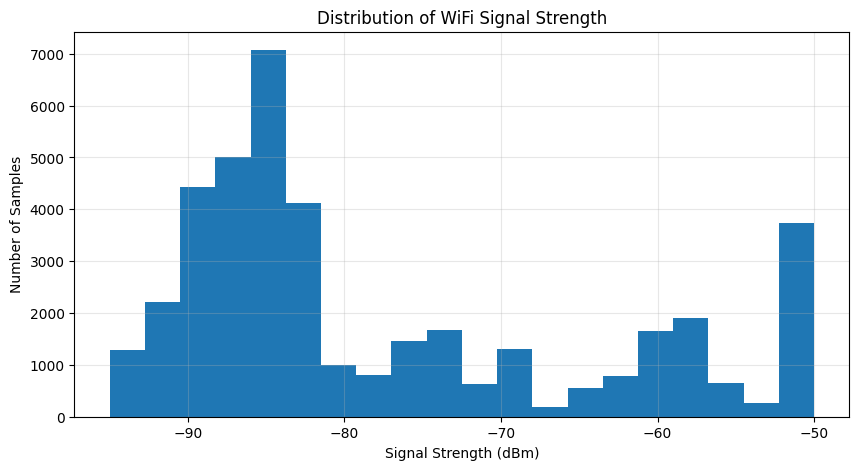

In [18]:
# ==========================================================
# Signal Strength Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    dataset["signal_strength"],
    bins=20
)

plt.title("Distribution of WiFi Signal Strength")

plt.xlabel("Signal Strength (dBm)")

plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)

plt.show()

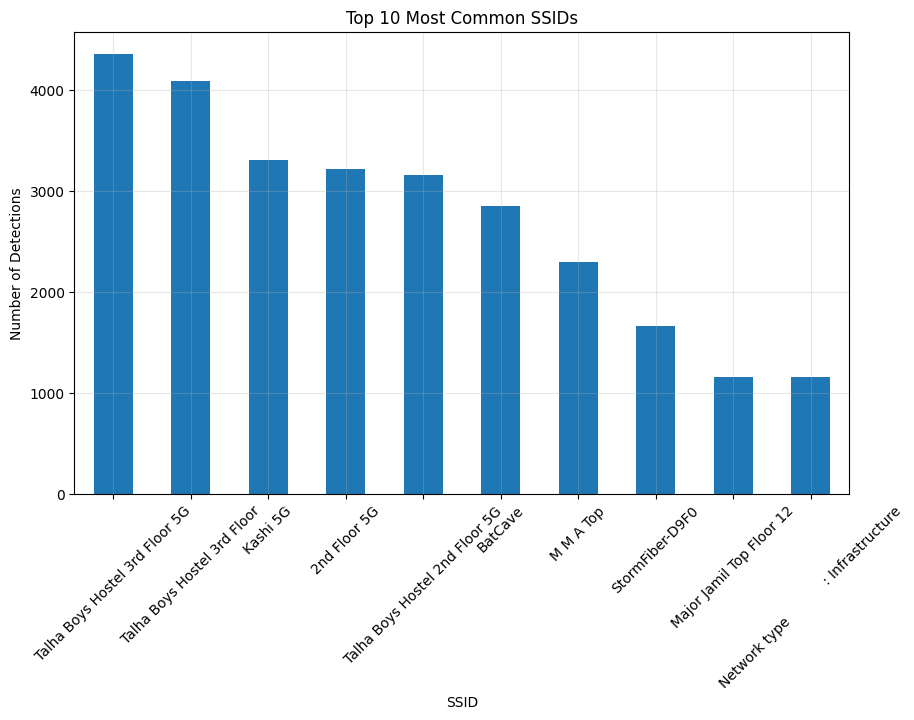

In [19]:
# ==========================================================
# Most Common SSIDs
# ==========================================================

top_ssids = dataset["ssid"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_ssids.plot(kind="bar")

plt.title("Top 10 Most Common SSIDs")

plt.xlabel("SSID")

plt.ylabel("Number of Detections")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

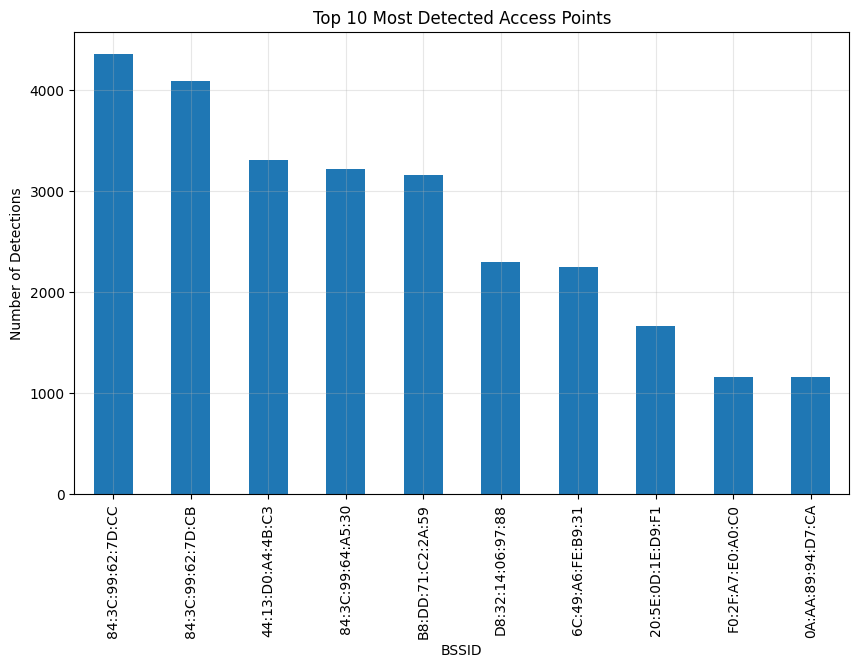

In [20]:
# ==========================================================
# Most Common BSSIDs
# ==========================================================

top_bssid = dataset["bssid"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_bssid.plot(kind="bar")

plt.title("Top 10 Most Detected Access Points")

plt.xlabel("BSSID")

plt.ylabel("Number of Detections")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

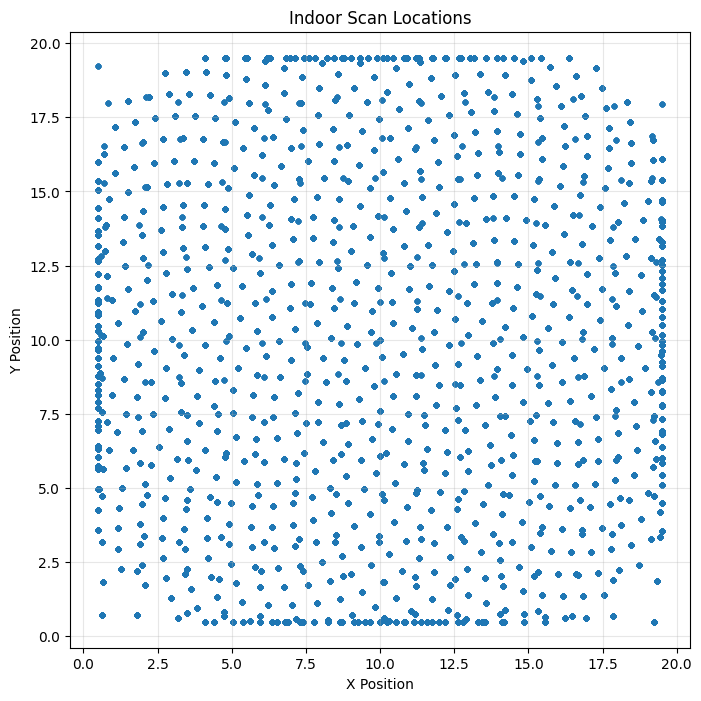

In [21]:
# ==========================================================
# Scan Locations
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    dataset["x_pos"],
    dataset["y_pos"],
    s=10,
    alpha=0.6
)

plt.title("Indoor Scan Locations")

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.grid(alpha=0.3)

plt.axis("equal")

plt.show()

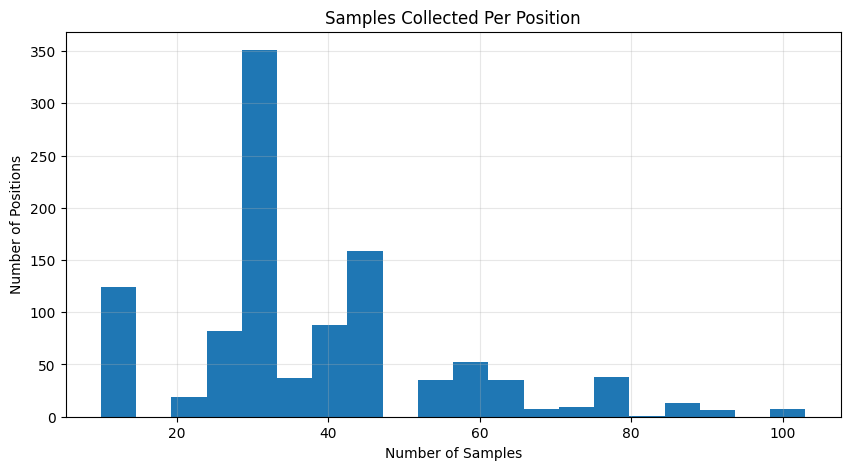

In [22]:
# ==========================================================
# Samples Per Position
# ==========================================================

samples_per_position = (
    dataset
    .groupby(["x_pos","y_pos"])
    .size()
)

plt.figure(figsize=(10,5))

plt.hist(samples_per_position, bins=20)

plt.title("Samples Collected Per Position")

plt.xlabel("Number of Samples")

plt.ylabel("Number of Positions")

plt.grid(alpha=0.3)

plt.show()

In [23]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Total Samples        : {len(dataset):,}")

print(f"Unique Positions     : {dataset[['x_pos','y_pos']].drop_duplicates().shape[0]}")

print(f"Unique SSIDs         : {dataset['ssid'].nunique()}")

print(f"Unique BSSIDs        : {dataset['bssid'].nunique()}")

print(f"Average RSSI         : {dataset['signal_strength'].mean():.2f} dBm")

EDA SUMMARY
Total Samples        : 40,783
Unique Positions     : 1063
Unique SSIDs         : 47
Unique BSSIDs        : 49
Average RSSI         : -77.56 dBm


# Section 5 — WiFi Fingerprint Generation

## Goal

Transform the raw WiFi scan records into a fingerprint matrix suitable for machine learning models.

In [24]:
# ==========================================================
# Scan Session Validation
# ==========================================================

scan_groups = dataset.groupby(
    ["timestamp", "x_pos", "y_pos", "source_file"]
)

print("=" * 60)
print("SCAN SESSION VALIDATION")
print("=" * 60)

print(f"Total WiFi Records : {len(dataset):,}")
print(f"Total Scan Sessions: {len(scan_groups):,}")

SCAN SESSION VALIDATION
Total WiFi Records : 40,783
Total Scan Sessions: 5,461


In [25]:
# ==========================================================
# Networks Per Scan
# ==========================================================

networks_per_scan = scan_groups.size()

print("\nNetworks Detected Per Scan")

print(networks_per_scan.describe())


Networks Detected Per Scan
count    5461.000000
mean        7.468046
std         3.529667
min         1.000000
25%         6.000000
50%         8.000000
75%         9.000000
max        15.000000
dtype: float64


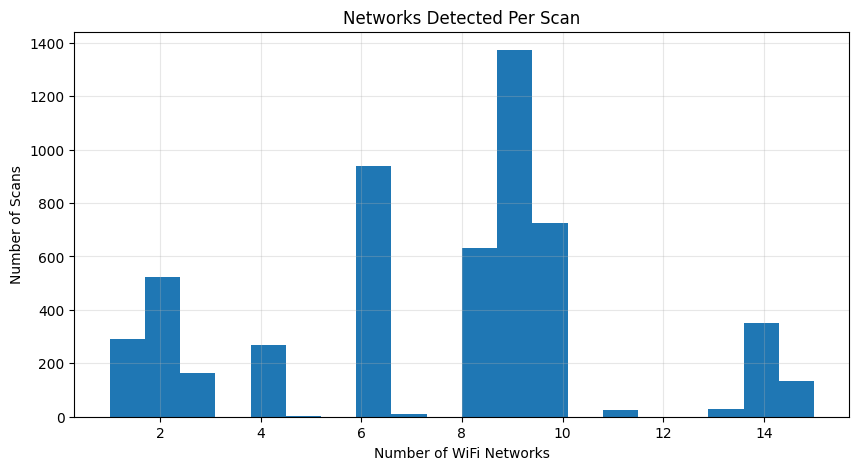

In [26]:
plt.figure(figsize=(10,5))

plt.hist(networks_per_scan, bins=20)

plt.title("Networks Detected Per Scan")

plt.xlabel("Number of WiFi Networks")

plt.ylabel("Number of Scans")

plt.grid(alpha=0.3)

plt.show()

In [27]:
# ==========================================================
# Generate Fingerprint Matrix
# ==========================================================

fingerprint_df = dataset.pivot_table(
    index=["timestamp", "x_pos", "y_pos", "source_file"],
    columns="bssid",
    values="signal_strength",
    aggfunc="max",
    fill_value=-100
)

fingerprint_df = fingerprint_df.reset_index()

print("Fingerprint Matrix Shape:")
print(fingerprint_df.shape)

Fingerprint Matrix Shape:
(5461, 53)


In [28]:
fingerprint_df.head()

bssid,timestamp,x_pos,y_pos,source_file,04:33:89:8B:A6:D0,04:95:E6:F6:5F:00,04:FE:8D:DD:9C:A0,08:40:F3:5D:24:B0,08:A6:F7:AF:A5:B9,08:AA:89:94:D7:CA,...,D0:59:95:B0:69:C7,D0:60:8C:AD:35:EB,D8:32:14:06:97:88,E0:61:4A:E1:43:61,E4:6F:13:F8:0F:E0,EE:F8:70:7C:2B:C2,F0:2F:A7:E0:A0:C0,F8:6C:E1:80:21:41,F8:6C:E1:8E:82:47,FC:E3:3C:46:3E:5C
0,2026-06-06 19:52:43.762,0.643035,0.703886,wifi_scan_20260607_005505.csv,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-100,-100,-100,-100,-100,-100
1,2026-06-06 19:52:43.762,0.643035,0.703886,wifi_scan_20260607_005602.csv,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-100,-100,-100,-100,-100,-100
2,2026-06-06 19:52:43.762,0.643035,0.703886,wifi_scan_20260607_010534.csv,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-100,-100,-100,-100,-100,-100
3,2026-06-06 19:52:46.009,1.810765,0.716554,wifi_scan_20260607_005505.csv,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-100,-100,-100,-100,-100,-100
4,2026-06-06 19:52:46.009,1.810765,0.716554,wifi_scan_20260607_005602.csv,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-100,-100,-100,-100,-100,-100


In [29]:
print("=" * 60)
print("FINGERPRINT SUMMARY")
print("=" * 60)

print(f"Rows (Scans)        : {fingerprint_df.shape[0]:,}")

print(f"Columns             : {fingerprint_df.shape[1]}")

print(f"BSSID Features      : {dataset['bssid'].nunique()}")

print(f"Unique Positions    : {fingerprint_df[['x_pos','y_pos']].drop_duplicates().shape[0]}")

FINGERPRINT SUMMARY
Rows (Scans)        : 5,461
Columns             : 53
BSSID Features      : 49
Unique Positions    : 1063


In [30]:
# ==========================================================
# Prepare ML Dataset
# ==========================================================

feature_columns = fingerprint_df.columns[4:]

X = fingerprint_df[feature_columns]

y = fingerprint_df[["x_pos", "y_pos"]]

print("Feature Matrix:", X.shape)

print("Target Matrix :", y.shape)

Feature Matrix: (5461, 49)
Target Matrix : (5461, 2)


In [31]:
# ==========================================================
# Save Fingerprint Dataset
# ==========================================================

fingerprint_df.to_csv(
    "fingerprint_dataset.csv",
    index=False
)

print("✅ Fingerprint dataset saved successfully.")

✅ Fingerprint dataset saved successfully.


# Section 6 — Feature Engineering & Data Preparation

## Goal

Prepare the WiFi fingerprint dataset for machine learning by creating the feature matrix, target matrix, and train/test split.

In [32]:
# ==========================================================
# Load Fingerprint Dataset
# ==========================================================

fingerprint_df = pd.read_csv("fingerprint_dataset.csv")

print("✅ Fingerprint dataset loaded successfully.")
print(f"Dataset Shape: {fingerprint_df.shape}")

✅ Fingerprint dataset loaded successfully.
Dataset Shape: (5461, 53)


In [33]:
# ==========================================================
# Create Feature and Target Matrices
# ==========================================================

feature_columns = fingerprint_df.columns[4:]

X = fingerprint_df[feature_columns]

y = fingerprint_df[["x_pos", "y_pos"]]

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

print(f"Number of Features : {X.shape[1]}")
print(f"Number of Samples  : {X.shape[0]}")
print(f"Target Dimensions  : {y.shape[1]}")

FEATURE ENGINEERING
Number of Features : 49
Number of Samples  : 5461
Target Dimensions  : 2


In [34]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training Samples : {X_train.shape}")
print(f"Testing Samples  : {X_test.shape}")

TRAIN / TEST SPLIT
Training Samples : (4368, 49)
Testing Samples  : (1093, 49)


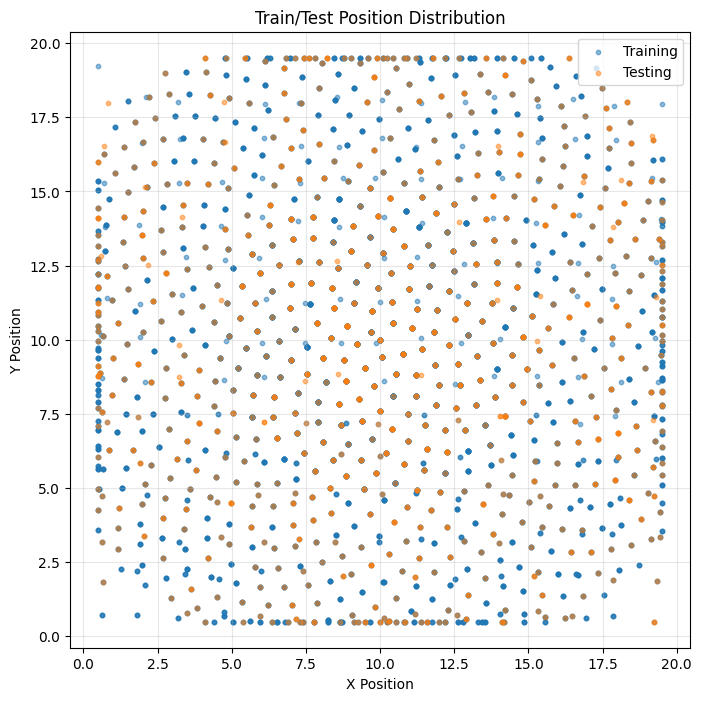

In [35]:
# ==========================================================
# Train/Test Position Distribution
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_train["x_pos"],
    y_train["y_pos"],
    s=10,
    alpha=0.5,
    label="Training"
)

plt.scatter(
    y_test["x_pos"],
    y_test["y_pos"],
    s=10,
    alpha=0.5,
    label="Testing"
)

plt.title("Train/Test Position Distribution")

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.legend()

plt.grid(alpha=0.3)

plt.axis("equal")

plt.show()

In [36]:
# ==========================================================
# Dataset Split Summary
# ==========================================================

print("=" * 60)
print("DATASET SPLIT SUMMARY")
print("=" * 60)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print(f"Training Ratio   : {len(X_train)/len(X):.2%}")
print(f"Testing Ratio    : {len(X_test)/len(X):.2%}")

DATASET SPLIT SUMMARY
Training Samples : 4,368
Testing Samples  : 1,093
Training Ratio   : 79.99%
Testing Ratio    : 20.01%


**Section 7 Goals**

We'll:

Train the first ML model.
Predict coordinates.
Measure errors.
Visualize predictions.
Save the trained model.

In [37]:
# ==========================================================
# KNN Baseline Model
# ==========================================================

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [38]:
n_neighbors = 5

In [39]:
# ==========================================================
# Train KNN Model
# ==========================================================

knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

knn_model.fit(X_train, y_train)

print("✅ KNN model trained successfully.")

✅ KNN model trained successfully.


In [40]:
# ==========================================================
# Predict Coordinates
# ==========================================================

predictions = knn_model.predict(X_test)

print("Prediction Shape:", predictions.shape)

Prediction Shape: (1093, 2)


In [41]:
# ==========================================================
# Model Evaluation
# ==========================================================

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("=" * 60)
print("KNN RESULTS")
print("=" * 60)

print(f"MAE : {mae:.3f}")

print(f"RMSE: {rmse:.3f}")

KNN RESULTS
MAE : 4.322
RMSE: 5.514


In [42]:
# ==========================================================
# Position Error
# ==========================================================

errors = np.sqrt(
    (predictions[:,0]-y_test["x_pos"])**2 +
    (predictions[:,1]-y_test["y_pos"])**2
)

print(f"Average Position Error : {errors.mean():.3f}")

print(f"Median Position Error  : {np.median(errors):.3f}")

print(f"Maximum Error          : {errors.max():.3f}")

Average Position Error : 6.813
Median Position Error  : 6.473
Maximum Error          : 19.780


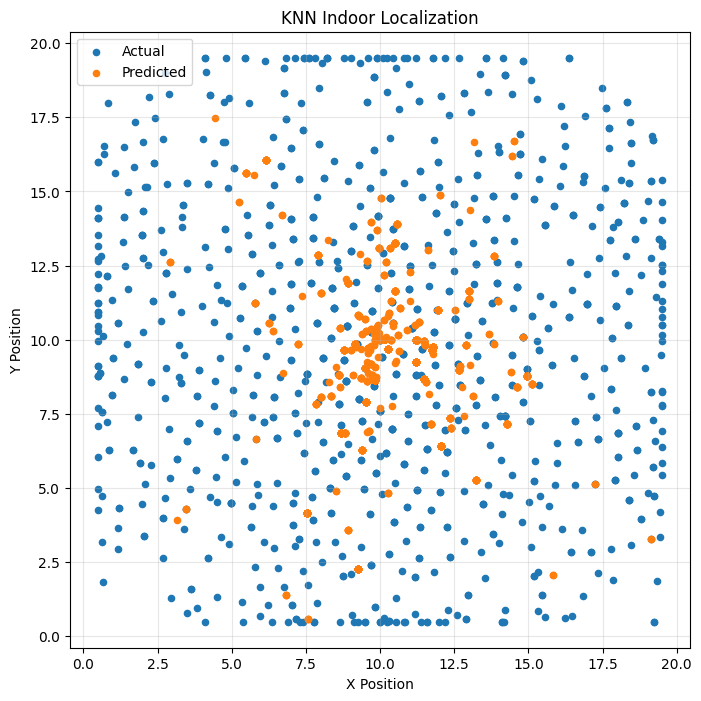

In [47]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test["x_pos"],
    y_test["y_pos"],
    s=20,
    label="Actual"
)

plt.scatter(
    predictions[:,0],
    predictions[:,1],
    s=20,
    label="Predicted"
)

plt.title("KNN Indoor Localization")

plt.xlabel("X Position")

plt.ylabel("Y Position")

plt.legend()

plt.grid(alpha=0.3)

plt.axis("equal")

plt.show()

In [48]:
import joblib

joblib.dump(
    knn_model,
    "models/knn_model.pkl"
)

print("✅ KNN model saved.")

✅ KNN model saved.


In [49]:
import os

os.makedirs("models", exist_ok=True)

**Section 8 — Tree-Based Models**

We'll train:

✅ Decision Tree Regressor
✅ Random Forest Regressor
✅ Extra Trees Regressor

All three predict (x, y) coordinates simultaneously.

In [50]:
# ==========================================================
# Tree-Based Models
# ==========================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [51]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    errors = np.sqrt(
        (predictions[:,0]-y_test["x_pos"])**2 +
        (predictions[:,1]-y_test["y_pos"])**2
    )

    print("="*60)
    print(model_name)
    print("="*60)

    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")

    print(f"Average Position Error : {errors.mean():.3f}")
    print(f"Median Position Error  : {np.median(errors):.3f}")
    print(f"Maximum Error          : {errors.max():.3f}")

    plt.figure(figsize=(8,8))

    plt.scatter(
        y_test["x_pos"],
        y_test["y_pos"],
        s=20,
        label="Actual"
    )

    plt.scatter(
        predictions[:,0],
        predictions[:,1],
        s=20,
        label="Predicted"
    )

    plt.title(model_name)

    plt.xlabel("X Position")

    plt.ylabel("Y Position")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.axis("equal")

    plt.show()

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "Average Error": errors.mean(),
        "Median Error": np.median(errors),
        "Maximum Error": errors.max()
    }

Decision Tree
MAE : 4.176
RMSE: 5.174
Average Position Error : 6.588
Median Position Error  : 6.744
Maximum Error          : 19.780


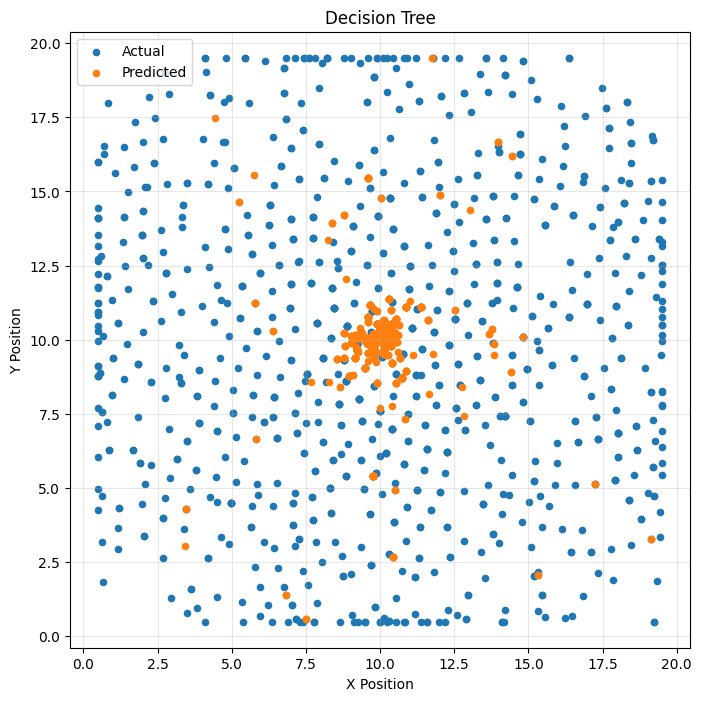

In [52]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

dt_results = evaluate_model(
    decision_tree,
    X_test,
    y_test,
    "Decision Tree"
)

Random Forest
MAE : 4.162
RMSE: 5.139
Average Position Error : 6.566
Median Position Error  : 6.753
Maximum Error          : 15.747


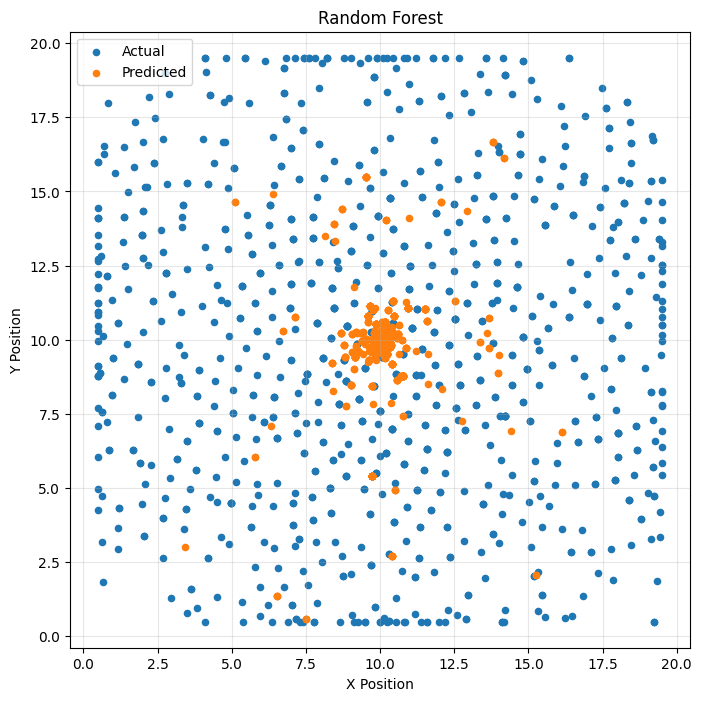

In [53]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    random_forest,
    X_test,
    y_test,
    "Random Forest"
)

Extra Trees
MAE : 4.174
RMSE: 5.168
Average Position Error : 6.584
Median Position Error  : 6.727
Maximum Error          : 19.780


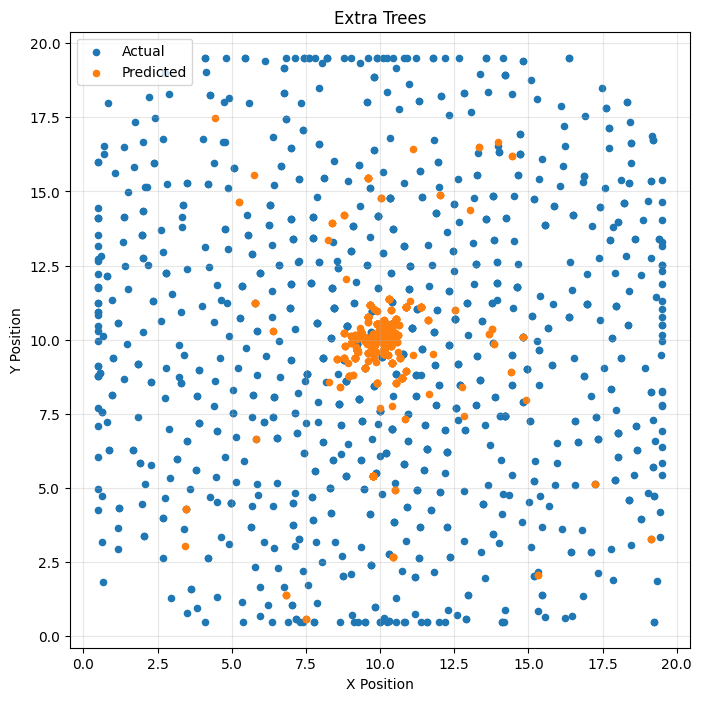

In [54]:
extra_trees = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(
    X_train,
    y_train
)

et_results = evaluate_model(
    extra_trees,
    X_test,
    y_test,
    "Extra Trees"
)

In [55]:
joblib.dump(decision_tree, "models/decision_tree.pkl")

joblib.dump(random_forest, "models/random_forest.pkl")

joblib.dump(extra_trees, "models/extra_trees.pkl")

print("✅ All tree models saved.")

✅ All tree models saved.


In [56]:
results = pd.DataFrame([
    dt_results,
    rf_results,
    et_results
])

results

,Model,MAE,RMSE,Average Error,Median Error,Maximum Error
0,Decision Tree,4.176184,5.173847,6.588278,6.744079,19.780233
1,Random Forest,4.162398,5.138738,6.566339,6.752987,15.747036
2,Extra Trees,4.173587,5.167732,6.584014,6.727457,19.780233


In [57]:
# ==========================================================
# Save Model Comparison Results
# ==========================================================

import os

os.makedirs("results", exist_ok=True)

results.to_csv(
    "results/model_comparison.csv",
    index=False
)

print("✅ Results saved successfully.")

✅ Results saved successfully.
